# Student Performance Prediction

Predicting final exam grades (G3) of secondary school students using demographic,
social, and academic features from the UCI Student Performance dataset.

**Goal:** Compare several regression models and identify which factors best explain
variation in final grades.

**Dataset:** [UCI Student Performance Data Set](https://archive.ics.uci.edu/dataset/320/student+performance) (Math course, 395 students, 33 features)

In [49]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Load Data

In [50]:
data=pd.read_csv('D:/multi-media/data cleainig/ml_sklearn/student/student-mat.csv',sep=';')
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


## 2. Initial Inspection
Checking data types, missing values, and column names before any processing.

In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [52]:
data.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## 3. Feature Grouping (Exploratory)
Grouping columns into semantic categories (demographics, family, study habits,
lifestyle) to guide the exploratory analysis below.

In [53]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [54]:
student=['school', 'sex', 'age', 'address', 'famsize', 'Pstatus']
stu_family=[ 'Medu', 'Fedu','Mjob', 'Fjob', 'guardian']
stu_studyPlan=['studytime','failures', 'schoolsup', 'famsup', 'paid','higher']
stu_life=[ 'activities','internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc','Walc','health', 'absences']
scores=['G1', 'G2', 'G3']
student=data[student]
stu_family=data[stu_family]
stu_studyPlan=data[stu_studyPlan]
stu_life=data[stu_life]
scores=data[scores]

## 4. Grade Distribution
Looking at the distribution of G1, G2, and G3 (first, second, and final period grades)
to understand the target variable before modeling.

In [55]:
G1Score=scores["G1"]
aveG1=np.mean(G1Score)
print(aveG1)
G2Score=scores["G2"]
aveG2=np.mean(G2Score)
print(aveG2)
G3Score=scores["G3"]
aveG3=np.mean(G3Score)
print(aveG3)

10.90886075949367
10.713924050632912
10.415189873417722


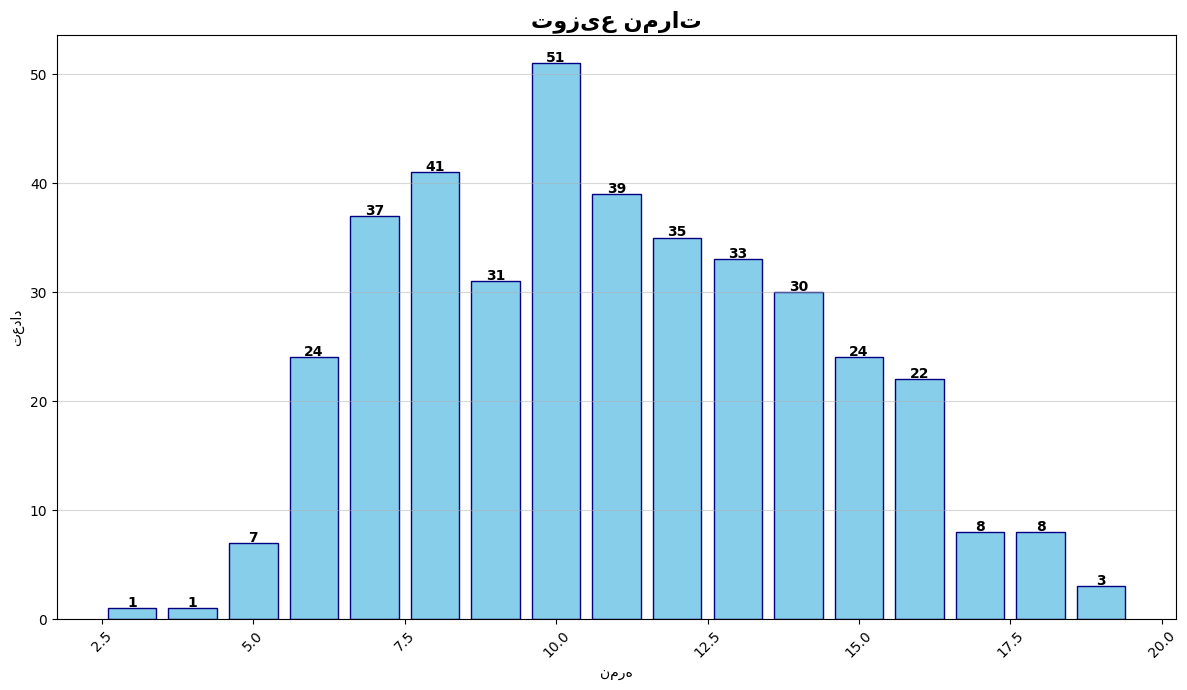

In [56]:
import matplotlib.pyplot as plt
import pandas as pd


freq = G1Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

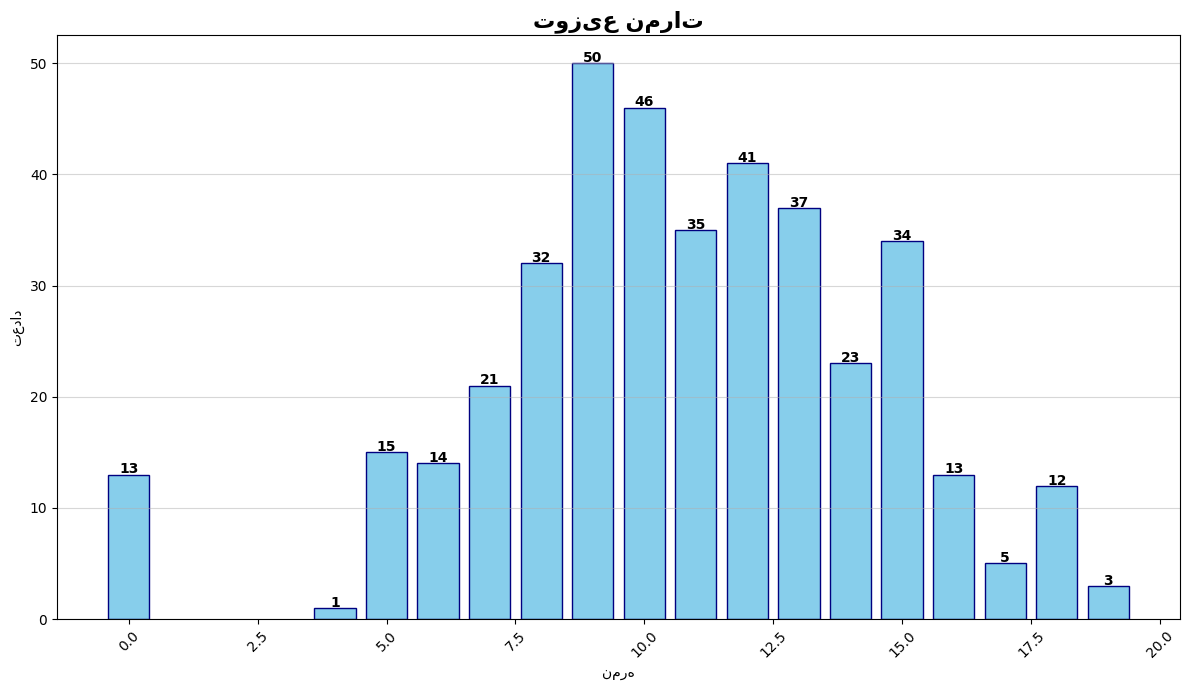

In [57]:
freq = G2Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

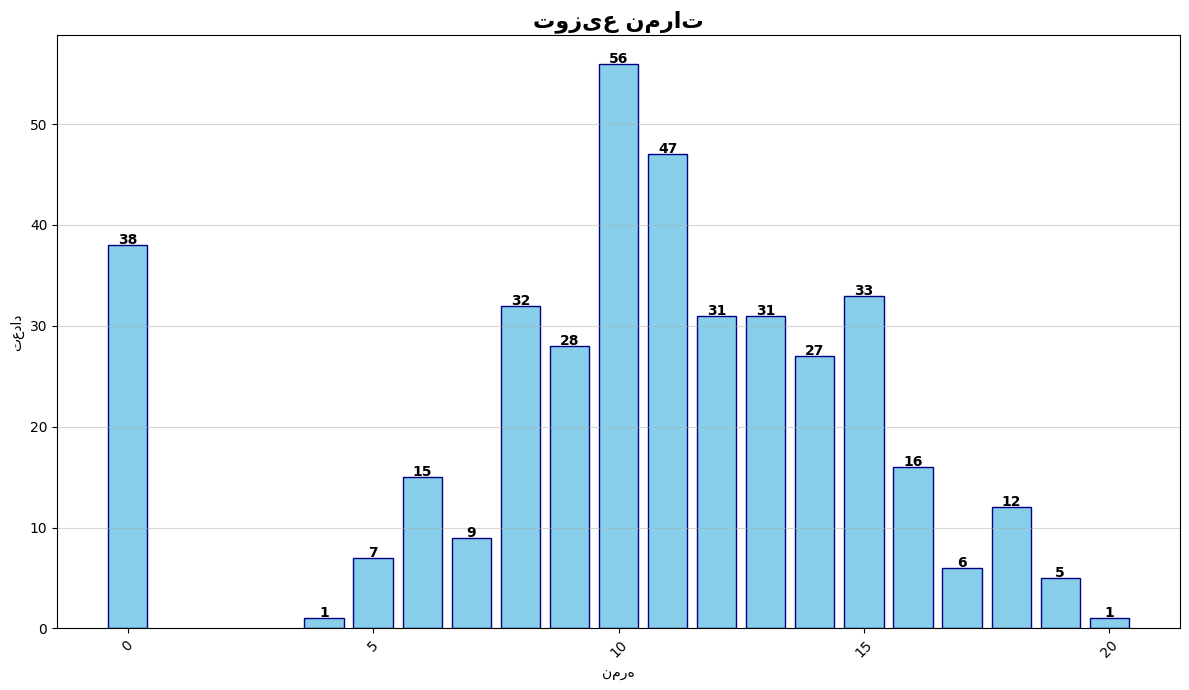

In [58]:
freq = G3Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Preprocessing Pipeline

Numerical features are standardized; categorical features are one-hot encoded.

> **Note on methodology:** G1 and G2 are grades from earlier periods of the *same*
> course and are strongly correlated with G3. Keeping them as features makes the
> prediction task considerably easier and less representative of predicting grades
> from demographic/behavioral factors alone. Results below include a comparison
> with and without G1/G2 (see Section 8).

In [59]:
target = data["G3"]
feature = data.drop(columns=["G2", "G3"])
x = feature
y = target


text_cols = x.select_dtypes(include=["object", "string"]).columns
x[text_cols] = x[text_cols].astype(object)

numerical_columns = x.select_dtypes(include=["int64"]).columns
categorical_columns = x.select_dtypes(include=["object"]).columns


numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)


## 6. Train/Test Split
80/20 split, fixed random state for reproducibility.

In [60]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## 7. Fit Preprocessing on Training Data
Fitting the preprocessor only on the training set and applying the same
transformation to test data, to avoid data leakage.

In [61]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [62]:
print(x_train_processed.shape)
print(x_test_processed.shape)

(316, 57)
(79, 57)


## 8. Model Comparison
Training and evaluating six regression models with default hyperparameters,
using MAE, RMSE, and R² as comparison metrics.

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [64]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [65]:
results = pd.DataFrame(results)
results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,1.596835,2.328693,0.735538
5,Gradient Boosting,1.634615,2.358518,0.728720
4,SVR,1.920148,2.827239,0.610180
0,Linear Regression,2.272191,2.897703,0.590507
1,Decision Tree,2.139241,3.239394,0.488240
3,KNN,2.663291,3.493937,0.404654
